# 📘 GloVe Word Embeddings in Google Colab

This notebook demonstrates how to load pre-trained GloVe embeddings, find similar words, and visualize word vectors using PCA.

👉 **Step 1**: Upload the `glove.6B.50d.txt` file using the file upload button below.


KeyboardInterrupt: 

Mounted at /content/drive


In [3]:
import os

In [5]:
import numpy as np


def load_glove_embeddings(file_path):
    embeddings = {}
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            values = line.strip().split()
            word = values[0]
            vector = np.array(values[1:], dtype="float32")
            embeddings[word] = vector
    return embeddings


# Load the uploaded GloVe file
glove_file_path = "glove.6B.50d.txt"
glove_embeddings = load_glove_embeddings(glove_file_path)
print(f"Loaded {len(glove_embeddings)} word vectors.")

Loaded 400000 word vectors.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
def find_similar_words(target_word, embeddings, top_n=10):
    if target_word not in embeddings:
        return f"'{target_word}' not found in embeddings."
    target_vector = embeddings[target_word]
    similarities = {}
    for word, vector in embeddings.items():
        if word == target_word:
            continue
        similarity = np.dot(target_vector, vector) / (
            np.linalg.norm(target_vector) * np.linalg.norm(vector)
        )
        similarities[word] = similarity
    sorted_words = sorted(similarities.items(), key=lambda item: item[1], reverse=True)
    return sorted_words[:top_n]


# Example usage
target = "king"
similar_words = find_similar_words(target, glove_embeddings)
print(f"Top 10 words similar to '{target}':")
for word, score in similar_words:
    print(f"{word}: {score:.4f}")

Top 10 words similar to 'king':
prince: 0.8236
queen: 0.7839
ii: 0.7746
emperor: 0.7736
son: 0.7667
uncle: 0.7627
kingdom: 0.7542
throne: 0.7540
brother: 0.7492
ruler: 0.7434


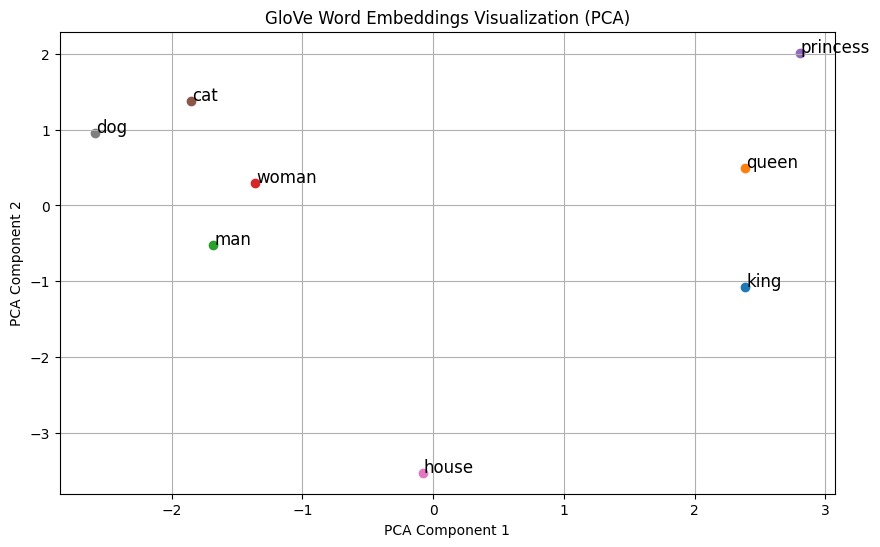

In [15]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Select words to visualize
selected_words = ["king", "queen", "man", "woman", "princess", "cat", "house", "dog"]
vectors = [
    glove_embeddings[word] for word in selected_words if word in glove_embeddings
]

# Reduce dimensions using PCA
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)

# Plot the word vectors
plt.figure(figsize=(10, 6))
for i, word in enumerate(selected_words):
    if word in glove_embeddings:
        x, y = reduced_vectors[i]
        plt.scatter(x, y)
        plt.text(x + 0.01, y + 0.01, word, fontsize=12)
plt.title("GloVe Word Embeddings Visualization (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()